## 1. Environment and Project Setup


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls -lah /content/drive/MyDrive/SDR

total 16K
drwx------ 4 root root 4.0K Oct  6 08:29 .
drwx------ 7 root root 4.0K Oct  6 08:39 ..
drwx------ 2 root root 4.0K Oct  6 06:11 data
drwx------ 2 root root 4.0K Oct  6 06:14 src


In [ ]:
!find /content/drive/MyDrive/SDR/data -maxdepth 2 -type f

/content/drive/MyDrive/SDR/data/X_test.npy
/content/drive/MyDrive/SDR/data/y_test.npy
/content/drive/MyDrive/SDR/data/X_train.npy
/content/drive/MyDrive/SDR/data/y_train.npy


## 2. Dataset Loading and Verification


In [ ]:
import numpy as np

y_train = np.load("/content/drive/MyDrive/SDR/data/y_train.npy")
y_test = np.load("/content/drive/MyDrive/SDR/data/y_test.npy")

print("Training classes:")
print("Damaged (0):", np.sum(y_train == 0))
print("Undamaged (1):", np.sum(y_train == 1))

print("\nTest classes:")
print("Damaged (0):", np.sum(y_test == 0))
print("Undamaged (1):", np.sum(y_test == 1))

Training classes:
Damaged (0): 2000
Undamaged (1): 2000

Test classes:
Damaged (0): 745
Undamaged (1): 715


In [ ]:
import numpy as np

X_train = np.load("/content/drive/MyDrive/SDR/data/X_train.npy", mmap_mode="r")
y_train = np.load("/content/drive/MyDrive/SDR/data/y_train.npy", mmap_mode="r")
X_test = np.load("/content/drive/MyDrive/SDR/data/X_test.npy", mmap_mode="r")
y_test = np.load("/content/drive/MyDrive/SDR/data/y_test.npy", mmap_mode="r")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (4000, 224, 224, 3)
y_train: (4000,)
X_test : (1460, 224, 224, 3)
y_test : (1460,)


In [ ]:
!find /content/drive/MyDrive/SDR/src -maxdepth 2 -type f

/content/drive/MyDrive/SDR/src/prepare_data.py
/content/drive/MyDrive/SDR/src/train.py


## 3. Training Pipeline Verification


In [ ]:
!cp /content/drive/MyDrive/SDR/src/train.py /content/train.py

In [ ]:
!python -m py_compile /content/train.py && echo "Syntax check PASSED"

Syntax check PASSED


In [ ]:
import torch
import torchvision
import numpy
import sklearn
import matplotlib
import seaborn

print("All required libraries imported successfully!")
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

All required libraries imported successfully!
PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
CUDA: True


In [ ]:
!python /content/train.py --help

usage: train.py [-h]
                [--model {resnet50,efficientnet_b0,mobilenet_v2,inception_v3}]
                [--data_dir DATA_DIR] [--out_dir OUT_DIR] [--epochs EPOCHS]
                [--finetune_epochs FINETUNE_EPOCHS] [--lr LR]
                [--finetune_lr FINETUNE_LR] [--batch_size BATCH_SIZE]
                [--val_frac VAL_FRAC] [--img_size IMG_SIZE]
                [--workers WORKERS] [--seed SEED]

Structural Damage Classification

options:
  -h, --help            show this help message and exit
  --model {resnet50,efficientnet_b0,mobilenet_v2,inception_v3}
  --data_dir DATA_DIR
  --out_dir OUT_DIR
  --epochs EPOCHS       Frozen-backbone training epochs
  --finetune_epochs FINETUNE_EPOCHS
                        Fine-tuning epochs
  --lr LR
  --finetune_lr FINETUNE_LR
  --batch_size BATCH_SIZE
  --val_frac VAL_FRAC
  --img_size IMG_SIZE
  --workers WORKERS
  --seed SEED


## 4. ResNet50 Experiment


In [ ]:
!mkdir -p /content/data

!cp /content/drive/MyDrive/SDR/data/X_train.npy /content/data/
!cp /content/drive/MyDrive/SDR/data/y_train.npy /content/data/
!cp /content/drive/MyDrive/SDR/data/X_test.npy /content/data/
!cp /content/drive/MyDrive/SDR/data/y_test.npy /content/data/

!ls -lh /content/data

total 784M
-rw------- 1 root root 210M Oct  6 08:57 X_test.npy
-rw------- 1 root root 575M Oct  6 08:57 X_train.npy
-rw------- 1 root root  12K Oct  6 08:57 y_test.npy
-rw------- 1 root root  32K Oct  6 08:57 y_train.npy


In [ ]:
import numpy as np

X_train = np.load("/content/data/X_train.npy", mmap_mode="r")
y_train = np.load("/content/data/y_train.npy")

X_test = np.load("/content/data/X_test.npy", mmap_mode="r")
y_test = np.load("/content/data/y_test.npy")

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_test :", X_test.shape, X_test.dtype)
print("y_test :", y_test.shape, y_test.dtype)

print("\nTraining classes:", np.bincount(y_train))
print("Test classes:", np.bincount(y_test))

X_train: (4000, 224, 224, 3) uint8
y_train: (4000,) int64
X_test : (1460, 224, 224, 3) uint8
y_test : (1460,) int64

Training classes: [2000 2000]
Test classes: [745 715]


In [ ]:
import torch
from torchvision import models

device = torch.device("cuda")

print("Loading ResNet50...")

model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V2
)

model = model.to(device)

print("ResNet50 loaded successfully!")
print("GPU:", torch.cuda.get_device_name(0))
print("Parameters:", sum(p.numel() for p in model.parameters()))

Loading ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


ResNet50 loaded successfully!
GPU: Tesla T4
Parameters: 25557032


In [ ]:
!mkdir -p /content/results

In [ ]:
!python /content/train.py \
    --model resnet50 \
    --data_dir /content/data \
    --out_dir /content/results \
    --epochs 5 \
    --finetune_epochs 5 \
    --batch_size 64 \
    --workers 2 \
    --seed 42

STRUCTURAL DAMAGE CLASSIFICATION
Device       : cuda
GPU          : Tesla T4
Model        : resnet50
Image size   : 224
Batch size   : 64

Loading dataset...
X_train shape : (4000, 224, 224, 3)
y_train shape : (4000,)
X_test shape  : (1460, 224, 224, 3)
y_test shape  : (1460,)
X_train dtype : uint8
X_test dtype  : uint8

Dataset split:
Training   : 3400
Validation : 600
Test       : 1460

Loading pretrained model...

PHASE: head
Learning rate: 0.001
Trainable parameters: 4,098
Epoch  1 [head    ] Train Loss: 0.4775 Train Acc: 0.7809 | Val Loss: 0.3957 Val Acc: 0.8200 | Time: 10s
  -> New best validation model
Epoch  2 [head    ] Train Loss: 0.3780 Train Acc: 0.8303 | Val Loss: 0.3692 Val Acc: 0.8467 | Time: 9s
  -> New best validation model
Epoch  3 [head    ] Train Loss: 0.3479 Train Acc: 0.8438 | Val Loss: 0.3580 Val Acc: 0.8483 | Time: 7s
  -> New best validation model
Epoch  4 [head    ] Train Loss: 0.3288 Train Acc: 0.8597 | Val Loss: 0.3510 Val Acc: 0.8500 | Time: 8s
  -> New bes

In [ ]:
!find /content/results -maxdepth 1 -type f -printf "%f\n"

best_resnet50.pt
resnet50_test_probs.npy
resnet50_confusion.png
resnet50_curves.png
resnet50_misclassified_idx.npy
resnet50_metrics.json


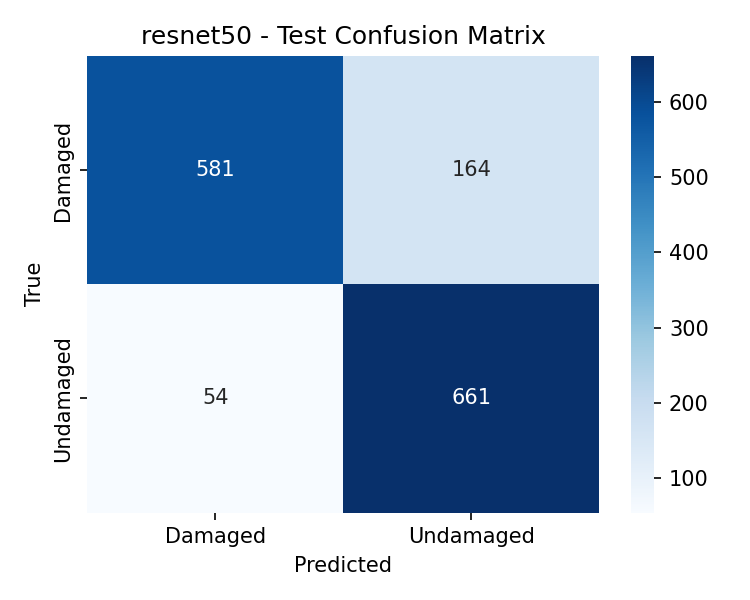

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/results/resnet50_confusion.png"))

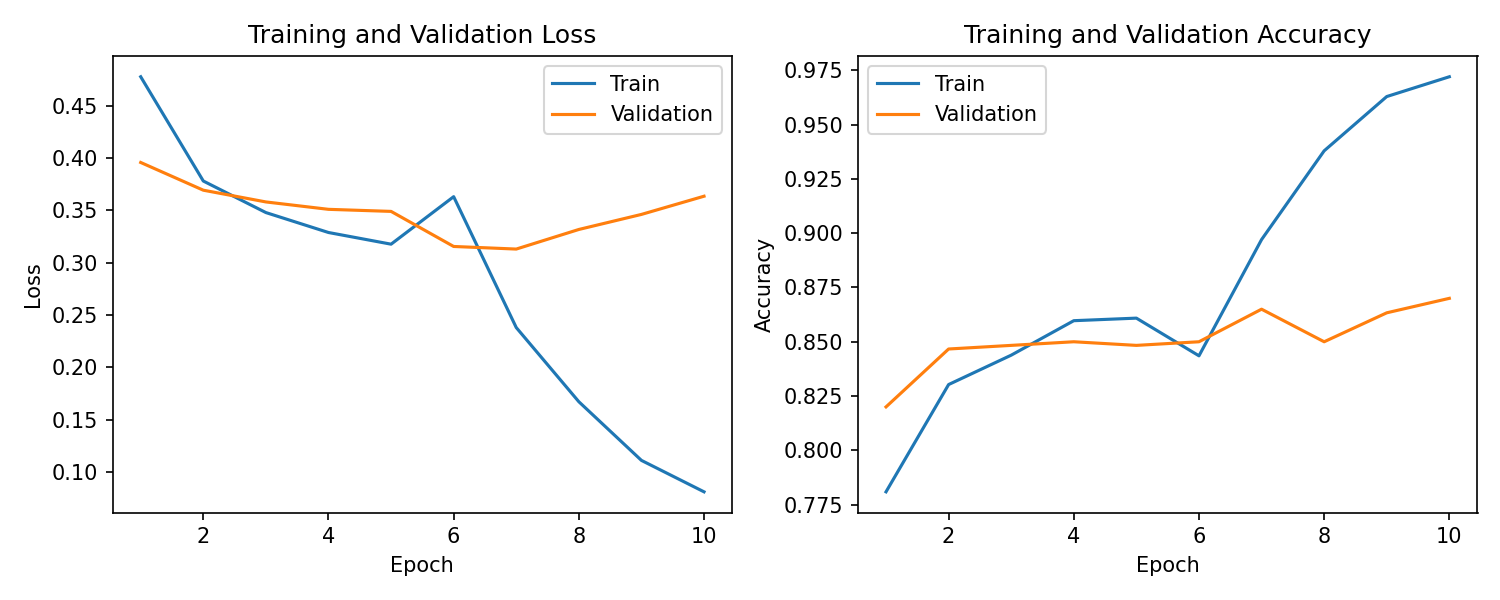

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/results/resnet50_curves.png"))

In [ ]:
import numpy as np

wrong = np.load(
    "/content/results/resnet50_misclassified_idx.npy"
)

print("Misclassified images:", len(wrong))
print("First 20 test indices:", wrong[:20])

Misclassified images: 218
First 20 test indices: [ 8 10 14 18 28 29 31 32 43 44 45 48 51 54 55 56 67 70 76 80]


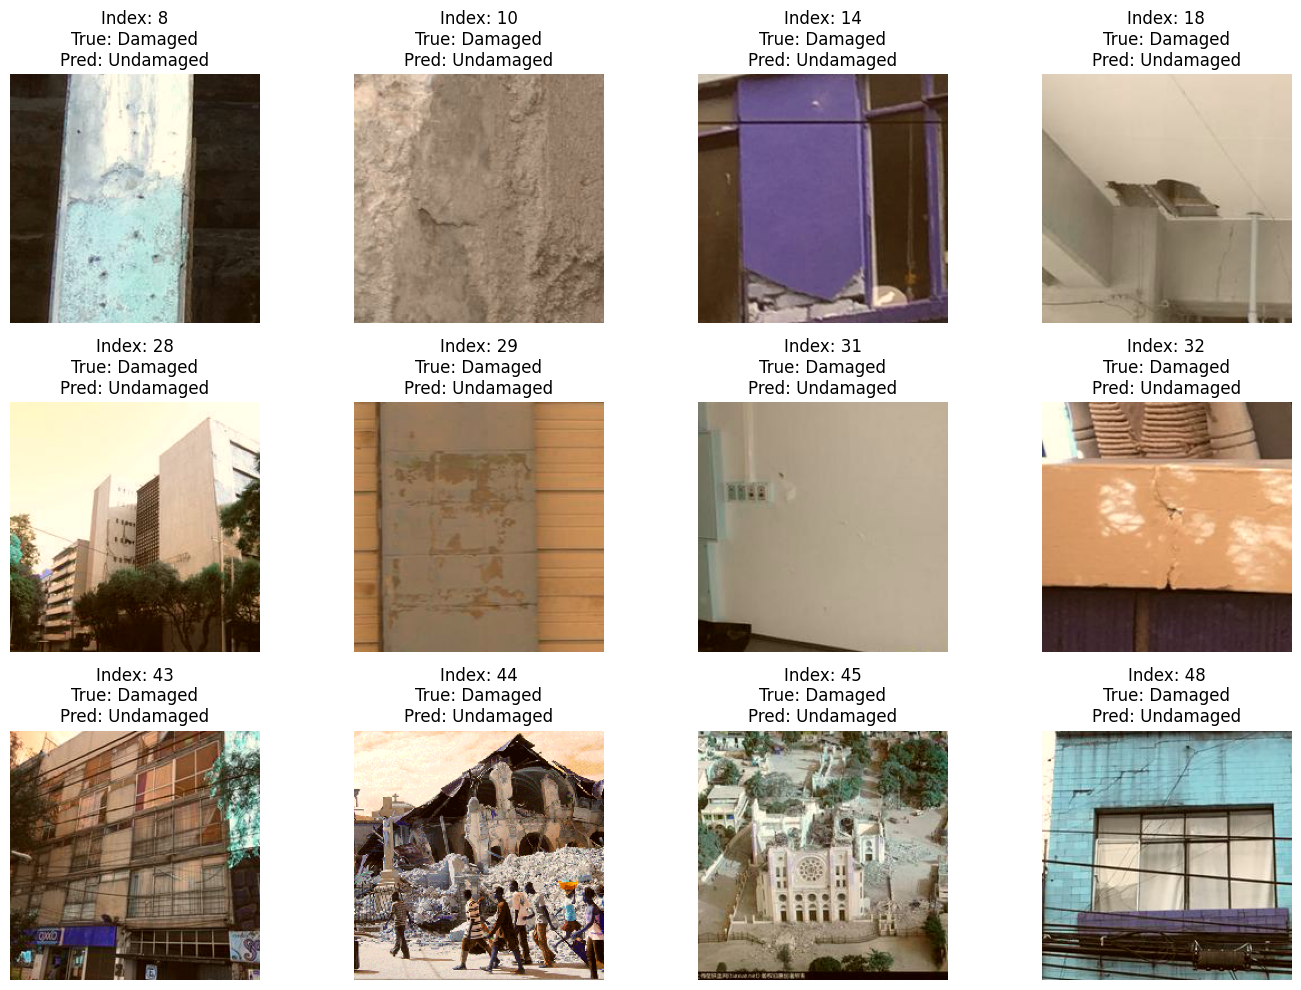

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load test data
X_test = np.load("/content/data/X_test.npy")
y_test = np.load("/content/data/y_test.npy")

# Load model predictions
wrong = np.load(
    "/content/results/resnet50_misclassified_idx.npy"
)

probs = np.load(
    "/content/results/resnet50_test_probs.npy"
)

# Take first 12 misclassified images
indices = wrong[:12]

fig, axes = plt.subplots(
    3, 4,
    figsize=(14, 10)
)

for ax, idx in zip(axes.ravel(), indices):

    true_label = y_test[idx]

    # Probability of class 1 = Undamaged
    predicted_label = 1 if probs[idx] >= 0.5 else 0

    ax.imshow(X_test[idx])

    ax.set_title(
        f"Index: {idx}\n"
        f"True: {'Damaged' if true_label == 0 else 'Undamaged'}\n"
        f"Pred: {'Damaged' if predicted_label == 0 else 'Undamaged'}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. EfficientNet-B0 Experiment


In [ ]:
import torch
from torchvision import models

print("Loading EfficientNet-B0...")

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

print("EfficientNet-B0 loaded successfully!")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Parameters:", sum(p.numel() for p in model.parameters()))

Loading EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s]


EfficientNet-B0 loaded successfully!
GPU: Tesla T4
Parameters: 5288548


In [ ]:
!python /content/train.py \
    --model efficientnet_b0 \
    --data_dir /content/data \
    --out_dir /content/results \
    --epochs 5 \
    --finetune_epochs 5 \
    --batch_size 64 \
    --workers 2 \
    --seed 42

STRUCTURAL DAMAGE CLASSIFICATION
Device       : cuda
GPU          : Tesla T4
Model        : efficientnet_b0
Image size   : 224
Batch size   : 64

Loading dataset...
X_train shape : (4000, 224, 224, 3)
y_train shape : (4000,)
X_test shape  : (1460, 224, 224, 3)
y_test shape  : (1460,)
X_train dtype : uint8
X_test dtype  : uint8

Dataset split:
Training   : 3400
Validation : 600
Test       : 1460

Loading pretrained model...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100% 20.5M/20.5M [00:00<00:00, 187MB/s]

PHASE: head
Learning rate: 0.001
Trainable parameters: 2,562
Epoch  1 [head    ] Train Loss: 0.4860 Train Acc: 0.7718 | Val Loss: 0.3998 Val Acc: 0.8117 | Time: 11s
  -> New best validation model
Epoch  2 [head    ] Train Loss: 0.3824 Train Acc: 0.8306 | Val Loss: 0.3710 Val Acc: 0.8283 | Time: 7s
  -> New best validation model
Epoch  3 [head    ] Train Loss: 0.3

In [ ]:
import numpy as np

probs = np.load("/content/results/efficientnet_b0_test_probs.npy")

print("Shape:", probs.shape)
print("Dimensions:", probs.ndim)
print("First 10 values:", probs[:10])

Shape: (1460,)
Dimensions: 1
First 10 values: [4.6225986e-01 3.6998611e-02 2.7928978e-01 1.3511062e-01 1.6939355e-03
 1.3382609e-02 5.1438680e-04 1.4518934e-01 7.8000087e-01 7.5047896e-03]


In [ ]:
import numpy as np

# Load test labels
y_test = np.load("/content/data/y_test.npy")

# Load saved probabilities
probs = np.load(
    "/content/results/efficientnet_b0_test_probs.npy"
)

# Treat saved value as probability of class 1 = Undamaged
preds = (probs >= 0.5).astype(np.int64)

# Calculate accuracy
accuracy = np.mean(preds == y_test)

# Find misclassified images
mis_idx = np.where(preds != y_test)[0]

print("=" * 50)
print("EFFICIENTNET-B0 SAVED PREDICTION CHECK")
print("=" * 50)

print("Probability shape :", probs.shape)
print("Predictions shape :", preds.shape)
print("Test labels shape :", y_test.shape)

print(f"\nCalculated accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print("Misclassified      :", len(mis_idx))

print("\nExpected from training:")
print("Test accuracy      : 87.26%")
print("Misclassified      : 186")

if abs(accuracy - 0.8726) < 0.01:
    print("\n✅ Prediction format confirmed!")
else:
    print("\n⚠️ Prediction format does NOT match the training result.")

EFFICIENTNET-B0 SAVED PREDICTION CHECK
Probability shape : (1460,)
Predictions shape : (1460,)
Test labels shape : (1460,)

Calculated accuracy : 0.8726 (87.26%)
Misclassified      : 186

Expected from training:
Test accuracy      : 87.26%
Misclassified      : 186

✅ Prediction format confirmed!


Total misclassified: 186


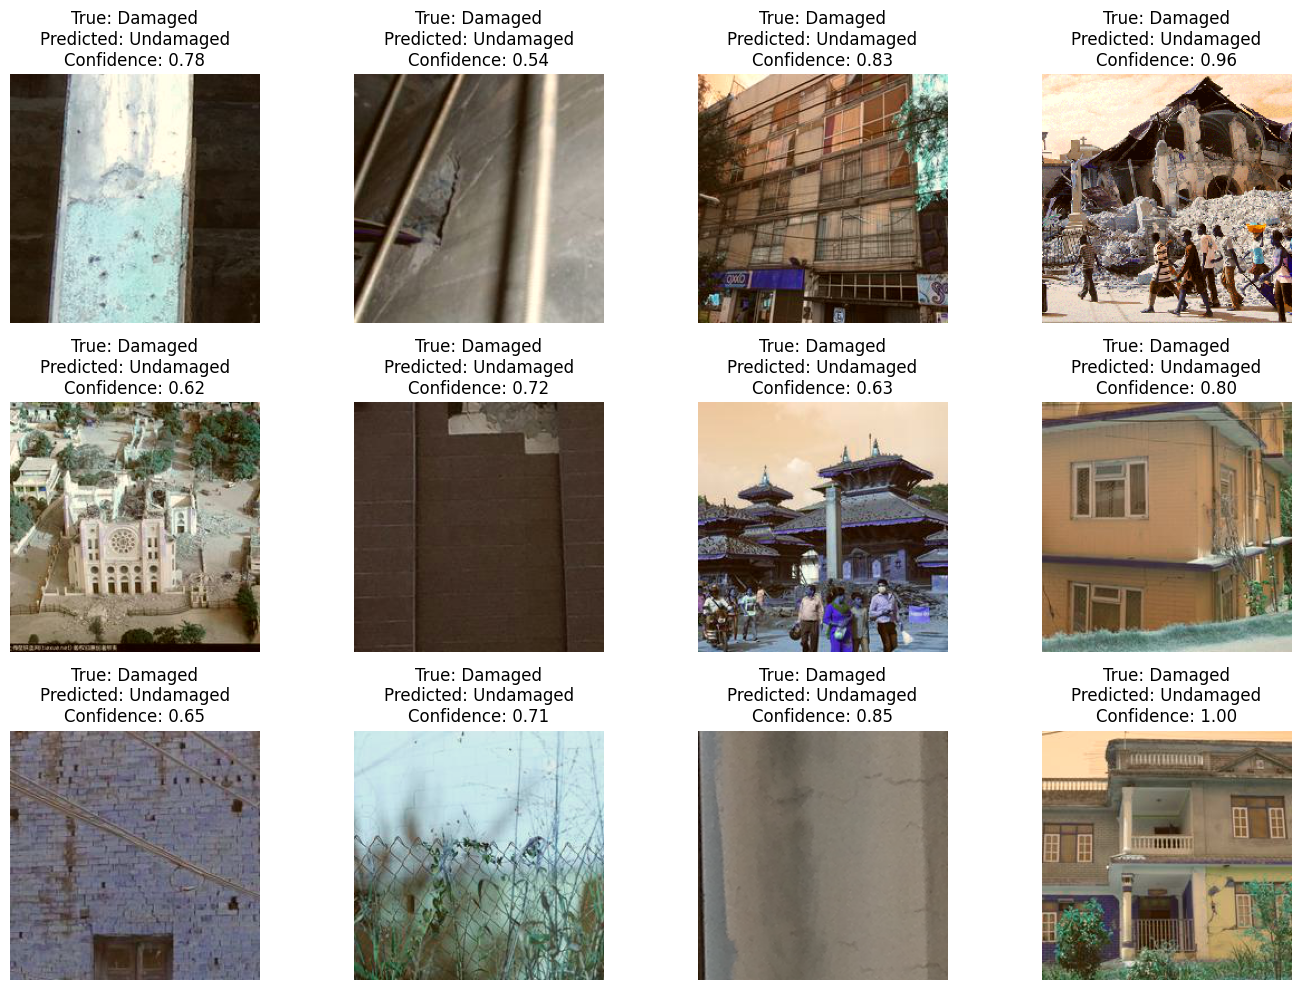

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load test data
X_test = np.load("/content/data/X_test.npy", mmap_mode="r")
y_test = np.load("/content/data/y_test.npy")

# Load saved probabilities
probs = np.load(
    "/content/results/efficientnet_b0_test_probs.npy"
)

# Saved value = probability of class 1 (Undamaged)
preds = (probs >= 0.5).astype(np.int64)

# Find actual mistakes
mis_idx = np.where(preds != y_test)[0]

print("Total misclassified:", len(mis_idx))

# Display first 12 genuine mistakes
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, idx in zip(axes.flat, mis_idx[:12]):

    true_label = "Damaged" if y_test[idx] == 0 else "Undamaged"
    pred_label = "Damaged" if preds[idx] == 0 else "Undamaged"

    confidence = (
        1 - probs[idx]
        if preds[idx] == 0
        else probs[idx]
    )

    ax.imshow(X_test[idx])

    ax.set_title(
        f"True: {true_label}\n"
        f"Predicted: {pred_label}\n"
        f"Confidence: {confidence:.2f}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
import os
import shutil

# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================
drive.mount('/content/drive')

# ============================================================
# 2. RESTORE train.py
# ============================================================
drive_train = "/content/drive/MyDrive/SDR/src/train.py"
local_train = "/content/train.py"

shutil.copy2(drive_train, local_train)

# ============================================================
# 3. RESTORE DATA
# ============================================================
drive_data = "/content/drive/MyDrive/SDR/data"
local_data = "/content/data"

os.makedirs(local_data, exist_ok=True)

for filename in [
    "X_train.npy",
    "y_train.npy",
    "X_test.npy",
    "y_test.npy"
]:
    src = os.path.join(drive_data, filename)
    dst = os.path.join(local_data, filename)

    if not os.path.exists(dst):
        print(f"Copying {filename}...")
        shutil.copy2(src, dst)
    else:
        print(f"{filename} already exists.")

# ============================================================
# 4. CHECK train.py
# ============================================================
print("\nChecking train.py...")
os.system("python -m py_compile /content/train.py")

# ============================================================
# 5. CHECK DATA
# ============================================================
import numpy as np

print("\nChecking dataset...")

X_train = np.load("/content/data/X_train.npy", mmap_mode="r")
y_train = np.load("/content/data/y_train.npy")

X_test = np.load("/content/data/X_test.npy", mmap_mode="r")
y_test = np.load("/content/data/y_test.npy")

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_test :", X_test.shape, X_test.dtype)
print("y_test :", y_test.shape, y_test.dtype)

print("Training classes:", np.bincount(y_train))
print("Test classes:", np.bincount(y_test))

# ============================================================
# 6. TRAIN MOBILENETV2
# ============================================================
print("\n" + "=" * 60)
print("STARTING MOBILENETV2 TRAINING")
print("=" * 60)

os.system("""
python /content/train.py \
    --model mobilenet_v2 \
    --data_dir /content/data \
    --out_dir /content/results \
    --epochs 5 \
    --finetune_epochs 5 \
    --batch_size 64 \
    --workers 2 \
    --seed 42
""")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying X_train.npy...
Copying y_train.npy...
Copying X_test.npy...
Copying y_test.npy...

Checking train.py...

Checking dataset...
X_train: (4000, 224, 224, 3) uint8
y_train: (4000,) int64
X_test : (1460, 224, 224, 3) uint8
y_test : (1460,) int64
Training classes: [2000 2000]
Test classes: [745 715]

STARTING MOBILENETV2 TRAINING


0

## 6. MobileNetV2 Experiment


In [ ]:
!python /content/train.py \
    --model mobilenet_v2 \
    --data_dir /content/data \
    --out_dir /content/results \
    --epochs 5 \
    --finetune_epochs 5 \
    --batch_size 64 \
    --workers 2 \
    --seed 42

STRUCTURAL DAMAGE CLASSIFICATION
Device       : cuda
GPU          : Tesla T4
Model        : mobilenet_v2
Image size   : 224
Batch size   : 64

Loading dataset...
X_train shape : (4000, 224, 224, 3)
y_train shape : (4000,)
X_test shape  : (1460, 224, 224, 3)
y_test shape  : (1460,)
X_train dtype : uint8
X_test dtype  : uint8

Dataset split:
Training   : 3400
Validation : 600
Test       : 1460

Loading pretrained model...

PHASE: head
Learning rate: 0.001
Trainable parameters: 2,562
Epoch  1 [head    ] Train Loss: 0.5070 Train Acc: 0.7429 | Val Loss: 0.4388 Val Acc: 0.8033 | Time: 10s
  -> New best validation model
Epoch  2 [head    ] Train Loss: 0.4208 Train Acc: 0.8029 | Val Loss: 0.4103 Val Acc: 0.8183 | Time: 8s
  -> New best validation model
Epoch  3 [head    ] Train Loss: 0.3963 Train Acc: 0.8265 | Val Loss: 0.3992 Val Acc: 0.8300 | Time: 7s
  -> New best validation model
Epoch  4 [head    ] Train Loss: 0.3906 Train Acc: 0.8276 | Val Loss: 0.4011 Val Acc: 0.8217 | Time: 8s
Epoch  5

## 7. Save Final EfficientNet-B0 Results


In [ ]:
import os
import shutil

# Local results from the completed EfficientNet-B0 run
local_results = "/content/results"

# Permanent Google Drive location
drive_results = "/content/drive/MyDrive/SDR/results"
os.makedirs(drive_results, exist_ok=True)

files_to_save = [
    "best_efficientnet_b0.pt",
    "efficientnet_b0_metrics.json",
    "efficientnet_b0_confusion.png",
    "efficientnet_b0_curves.png",
    "efficientnet_b0_misclassified_idx.npy",
    "efficientnet_b0_test_probs.npy",
]

print("Checking and saving EfficientNet-B0 results...\n")

for filename in files_to_save:
    src = os.path.join(local_results, filename)
    dst = os.path.join(drive_results, filename)

    if os.path.isfile(src):
        shutil.copy2(src, dst)
        print(f"✅ Saved: {filename}")
    else:
        print(f"❌ Missing: {filename}")

print("\n" + "=" * 60)
print("VERIFYING GOOGLE DRIVE")
print("=" * 60)

for filename in files_to_save:
    path = os.path.join(drive_results, filename)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✅ {filename}  ({size_mb:.2f} MB)")
    else:
        print(f"❌ {filename}")

print("\n📁 Permanent location:")
print("/My Drive/SDR/results/")

Checking and saving EfficientNet-B0 results...

✅ Saved: best_efficientnet_b0.pt
✅ Saved: efficientnet_b0_metrics.json
✅ Saved: efficientnet_b0_confusion.png
✅ Saved: efficientnet_b0_curves.png
✅ Saved: efficientnet_b0_misclassified_idx.npy
✅ Saved: efficientnet_b0_test_probs.npy

VERIFYING GOOGLE DRIVE
✅ best_efficientnet_b0.pt  (15.57 MB)
✅ efficientnet_b0_metrics.json  (0.00 MB)
✅ efficientnet_b0_confusion.png  (0.04 MB)
✅ efficientnet_b0_curves.png  (0.08 MB)
✅ efficientnet_b0_misclassified_idx.npy  (0.00 MB)
✅ efficientnet_b0_test_probs.npy  (0.01 MB)

📁 Permanent location:
/My Drive/SDR/results/


## 8. Inference Pipeline


In [ ]:
%%writefile /content/drive/MyDrive/SDR/src/predict.py

import argparse
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image


CLASS_NAMES = {
    0: "Damaged",
    1: "Undamaged"
}


def load_model(model_path, device):

    model = models.efficientnet_b0(weights=None)

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        2
    )

    checkpoint = torch.load(
        model_path,
        map_location=device
    )

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model = model.to(device)
    model.eval()

    return model


def predict(model, image_path, device):

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    image = Image.open(image_path).convert("RGB")

    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )[0]

    predicted_class = torch.argmax(
        probabilities
    ).item()

    damaged_probability = probabilities[0].item()
    undamaged_probability = probabilities[1].item()

    confidence = probabilities[
        predicted_class
    ].item()

    prediction = CLASS_NAMES[predicted_class]

    print("\nSTRUCTURAL DAMAGE RECOGNITION")
    print("--------------------------------")
    print(f"Image: {image_path}")
    print(f"Prediction: {prediction.upper()}")
    print(f"Confidence: {confidence * 100:.2f}%")
    print(f"Damaged probability: {damaged_probability * 100:.2f}%")
    print(f"Undamaged probability: {undamaged_probability * 100:.2f}%")

    return prediction, confidence


def main():

    parser = argparse.ArgumentParser(
        description="Predict structural damage from an image."
    )

    parser.add_argument(
        "--image",
        required=True,
        help="Path to the input image"
    )

    parser.add_argument(
        "--model",
        default="results/best_efficientnet_b0.pt",
        help="Path to the trained EfficientNet-B0 model"
    )

    args = parser.parse_args()

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print(f"Device: {device}")

    model_path = Path(args.model)
    image_path = Path(args.image)

    if not model_path.exists():
        raise FileNotFoundError(
            f"Model file not found: {model_path}"
        )

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image file not found: {image_path}"
        )

    model = load_model(
        model_path,
        device
    )

    predict(
        model,
        image_path,
        device
    )


if __name__ == "__main__":
    main()

Overwriting /content/drive/MyDrive/SDR/src/predict.py


## 9. Final Demo Predictions


In [ ]:
import numpy as np

probs = np.load(
    '/content/drive/MyDrive/SDR/results/efficientnet_b0_test_probs.npy'
)

y_test = np.load(
    '/content/drive/MyDrive/SDR/data/y_test.npy'
)

# Find correctly classified DAMAGED images
preds = (probs >= 0.5).astype(int)

correct_damaged = np.where(
    (y_test == 0) & (preds == 0)
)[0]

# Highest damaged probability
best_idx = correct_damaged[
    np.argmax(1 - probs[correct_damaged])
]

print("Best damaged image index:", best_idx)
print("Actual class: Damaged")
print("Damaged probability:", (1 - probs[best_idx]) * 100)
print("Undamaged probability:", probs[best_idx] * 100)

Best damaged image index: 542
Actual class: Damaged
Damaged probability: 99.99993
Undamaged probability: 6.769282e-05


In [ ]:
from PIL import Image
import numpy as np

X_test = np.load('/content/drive/MyDrive/SDR/data/X_test.npy')

Image.fromarray(
    X_test[542].astype(np.uint8)
).save('/content/damaged_demo.jpg')

print("Saved: /content/damaged_demo.jpg")

Saved: /content/damaged_demo.jpg


In [ ]:
!python /content/drive/MyDrive/SDR/src/predict.py \
    --image /content/damaged_demo.jpg \
    --model /content/drive/MyDrive/SDR/results/best_efficientnet_b0.pt

Device: cuda

STRUCTURAL DAMAGE RECOGNITION
--------------------------------
Image: /content/damaged_demo.jpg
Prediction: DAMAGED
Confidence: 100.00%
Damaged probability: 100.00%
Undamaged probability: 0.00%


In [ ]:
import numpy as np

probs = np.load(
    '/content/drive/MyDrive/SDR/results/efficientnet_b0_test_probs.npy'
)

y_test = np.load(
    '/content/drive/MyDrive/SDR/data/y_test.npy'
)

# Find correctly classified UNDAMAGED images
preds = (probs >= 0.5).astype(int)

correct_undamaged = np.where(
    (y_test == 1) & (preds == 1)
)[0]

# Highest undamaged probability
best_idx = correct_undamaged[
    np.argmax(probs[correct_undamaged])
]

print("Best undamaged image index:", best_idx)
print("Actual class: Undamaged")
print("Undamaged probability:", probs[best_idx] * 100)
print("Damaged probability:", (1 - probs[best_idx]) * 100)

Best undamaged image index: 1309
Actual class: Undamaged
Undamaged probability: 99.98981
Damaged probability: 0.010192394


In [ ]:
from PIL import Image
import numpy as np

X_test = np.load('/content/drive/MyDrive/SDR/data/X_test.npy')

Image.fromarray(
    X_test[1309].astype(np.uint8)
).save('/content/undamaged_demo.jpg')

print("Saved: /content/undamaged_demo.jpg")

Saved: /content/undamaged_demo.jpg


In [ ]:
!python /content/drive/MyDrive/SDR/src/predict.py \
    --image /content/undamaged_demo.jpg \
    --model /content/drive/MyDrive/SDR/results/best_efficientnet_b0.pt

Device: cuda

STRUCTURAL DAMAGE RECOGNITION
--------------------------------
Image: /content/undamaged_demo.jpg
Prediction: UNDAMAGED
Confidence: 99.99%
Damaged probability: 0.01%
Undamaged probability: 99.99%
